# Seminar 03: Wasserstein GAN

In this notebook, we'll explore **Wasserstein Generative Adversarial Networks (WGAN)** and their modern variants:

1. **WGAN** — the original approach that replaces the traditional discriminator with a "critic" and uses the **Wasserstein (Earth-Mover) distance** as the objective.
2. **WGAN-GP** — WGAN with Gradient Penalty (improves stability and enforces a **1-Lipschitz constraint** by penalizing deviations from unit gradient norm).
3. **WGAN + Spectral Normalization** — an alternative way to enforce the Lipschitz constraint on the critic via **spectral normalization** of its weights.

## 1. Introduction to WGAN

### 1.1 Wasserstein (Earth-Mover) Distance

<center>
Earth Mover Distance (EMD, Wasserstein) distance illustration

![](https://qph.fs.quoracdn.net/main-qimg-b579b7e100750529c32e9f209f53f8a1.webp)
</center>

The **Wasserstein distance** (or Earth-Mover distance) between two probability distributions $p$ and $q$ is:

$$
W(p, q) \;=\; \inf_{\gamma \in \Pi(p, q)} \;\mathbb{E}_{(x, y) \sim \gamma} \bigl[\| x - y \|\bigr],
$$

where $\Pi(p, q)$ is the set of all joint distributions whose marginals are $p$ and $q$. Intuitively, you can think of $W(p, q)$ as the **minimum total cost** of "transporting" mass from $p$ to $q$.

While this distance can be expensive to compute in high dimensions, the **Kantorovich-Rubinstein duality** gives an alternative:

$$
W(p, q) \;=\; \sup_{\| f \|_{\mathrm{Lip}} \le 1}\;\mathbb{E}_{x \sim p}[f(x)] \;-\;\mathbb{E}_{y \sim q}[f(y)],
$$

where where sup is the least upper bound and $\| f \|_{\mathrm{Lip}} \le 1$ means $f$ is a **1-Lipschitz function**, i.e.
$$
\forall\, x, y,\quad |f(x) - f(y)| \;\le\; \| x - y \|.
$$

### 1.2 WGAN Objective

We replace the usual GAN discriminator with a **critic** $D$, which outputs a real-valued score (no sigmoid). Suppose we have:
- A **generator** $G$ mapping noise $z$ to fake samples $G(z)$.
- A **critic** $D$ that tries to estimate how "real" a sample is (under the Wasserstein perspective).

**WGAN loss** can be written as:

$$
\min_{G}\; \max_{D \,\in\, \mathcal{D}} \;\;\mathbb{E}_{x \sim p_{\text{data}}}\bigl[D(x)\bigr]
\;-\; \mathbb{E}_{z \sim p_z}\bigl[D\bigl(G(z)\bigr)\bigr],
$$

where $\mathcal{D}$ is the set of 1-Lipschitz functions. The critic wants to **maximize** the difference of the average scores on real vs. fake data, and the generator wants to **minimize** it. 

In terms of **training losses**, we commonly write:
- **Critic ($D$) loss**:
  $$
  L_D \;=\; - \mathbb{E}_{x \sim p_{\text{data}}}[D(x)] \;+\; \mathbb{E}_{z \sim p_z}[D(G(z))].
  $$
  (The critic tries to push this difference up—hence the negative sign in front of the real part.)

- **Generator ($G$) loss**:
  $$
  L_G \;=\; -\mathbb{E}_{z \sim p_z}\bigl[D(G(z))\bigr].
  $$
  (The generator wants to get a higher critic score on fakes, so it tries to **minimize** the negative of it.)

In [17]:
import os
import zipfile
import torch
import gdown
from torch.utils.data import Dataset
from torchvision import transforms
import re
from PIL import Image

try:
    from natsort import natsorted
    SORT_FN = natsorted
except ImportError:
    # fallback to regular sorted if natsort is not available
    SORT_FN = sorted


class CelebADataset(Dataset):
    """
    Custom Dataset class for the CelebA dataset. Automatically downloads
    data and annotations from Google Drive if not found in the specified root_dir.

    Args:
        root_dir (str): The directory to store (or locate) the CelebA data.
        transform (callable, optional): Optional transform to be applied
            on a PIL Image sample.
    """

    def __init__(self, 
                 root_dir: str = "../data/celeba",
                 transform: transforms.Compose = None):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        
        self.header = None

        # The unzipped folder will be <root_dir>/img_align_celeba
        self.dataset_folder = os.path.join(root_dir, "img_align_celeba")
        if not os.path.isdir(self.dataset_folder):
            # If folder doesn't exist, attempt to download & unzip
            self._download_images()

        # Load file names
        self.filenames = os.listdir(self.dataset_folder)
        # Ensure consistent ordering (important if you rely on index-based consistency)
        self.filenames = SORT_FN(self.filenames)

        # Check for attribute files in the provided folder
        attr_folder = os.path.join(root_dir, "annotations")
        if not os.path.isdir(attr_folder):
            os.makedirs(attr_folder, exist_ok=True)
            self._download_annotations(attr_folder)

        # Locate and parse the list_attr_celeba.txt file
        attr_file_path = os.path.join(attr_folder, "list_attr_celeba.txt")
        if not os.path.isfile(attr_file_path):
            raise FileNotFoundError(
                f"Could not find 'list_attr_celeba.txt' in the annotations folder."
            )

        # Load attributes
        self.annotations = []
        with open(attr_file_path, "r") as f:
            lines = f.read().splitlines()

        # First line has the number of images, second line has the attribute names
        # The rest lines each correspond to one image
        for i, line in enumerate(lines):
            # line might have variable spaces, so split robustly
            line = re.sub(r"\s+", " ", line.strip())
            if i == 0:
                continue  # number of images
            elif i == 1:
                # header line with attribute names
                self.header = line.split(" ")
            else:
                parts = line.split(" ")
                filename = parts[0]
                # the rest are attribute labels
                attr_vals = [int(val) for val in parts[1:]]
                self.annotations.append((filename, attr_vals))

        # Convert to a dict: filename -> attribute array
        # so we can quickly look up attributes by filename
        self.attr_map = {
            fn: torch.tensor(attr_vals, dtype=torch.long)
            for fn, attr_vals in self.annotations
        }

    def _download_images(self):
        """
        If the CelebA folder isn't found, download and extract the image dataset from Google Drive.
        """
        os.makedirs(self.root_dir, exist_ok=True)
        zip_path = os.path.join(self.root_dir, "img_align_celeba.zip")

        if not os.path.isfile(zip_path):
            download_url = "https://drive.google.com/file/d/0B7EVK8r0v71pZjFTYXZWM3FlRnM"
            print("Downloading CelebA dataset from Google Drive. This might take a while...")
            gdown.download(download_url, zip_path, quiet=False, fuzzy=True)
        else:
            print(f"Found existing ZIP file at {zip_path}. Skipping download.")

        print(f"Extracting '{zip_path}'...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(self.root_dir)
        print("Extraction finished.")

    def _download_annotations(self, annotation_folder):
        """
        Download annotations from Google Drive if they are missing.
        """
        attr_file_path = os.path.join(annotation_folder, "list_attr_celeba.txt")
        if not os.path.isfile(attr_file_path):
            print("Downloading annotations for CelebA...")
            annotation_url = "https://drive.google.com/drive/folders/0B7EVK8r0v71pOC0wOVZlQnFfaGs"
            #gdown.download_folder(annotation_url, output=annotation_folder, quiet=False, fuzzy=True)
            gdown.download_folder(annotation_url, output=annotation_folder, quiet=False)
        else:
            print(f"Annotations already exist in '{annotation_folder}'. Skipping download.")

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): index of the sample

        Returns:
            tuple: (image, info_dict) where:
                image is the transformed PIL image,
                info_dict is a dictionary containing:
                    - 'filename': str
                    - 'idx': int
                    - 'attributes': torch.Tensor of shape (#attributes,)
        """
        img_name = self.filenames[idx]
        img_path = os.path.join(self.dataset_folder, img_name)

        # Load the image
        img = Image.open(img_path).convert("RGB")

        # Apply transforms
        if self.transform is not None:
            img = self.transform(img)

        # Fetch attributes (if they exist in the attr_map; some extra files might appear)
        attributes = self.attr_map.get(img_name, torch.zeros(40, dtype=torch.long))

        # Return both
        info_dict = {
            "filename": img_name,
            "idx": idx,
            "attributes": attributes
        }
        return img, info_dict


## 2. Data Preparation

We'll use the **CelebA** dataset as an example.

Below is a simple data loading pipeline.

In [18]:
import os
import sys
sys.path.append(os.path.abspath('../utils/datasets'))

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torch.nn.utils import spectral_norm

from tqdm.auto import tqdm
#import celeba

torch.backends.cudnn.benchmark = True

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    ("mps" if torch.backends.mps.is_available() else "cpu")
)

print(f"Using device: {device}")

Using device: mps


In [19]:
# Data Hyperparameters
image_size = 64
batch_size = 1024

# Define transforms
data_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(), # PIL Image -> Tensor
    transforms.Normalize([0.5]*3, [0.5]*3),  # for RGB, normalize each channel
])

dataset=CelebADataset(root_dir='../data/celeba',
                               transform=data_transform)

'''dataset = celeba.CelebADataset(root_dir='../data/celeba',
                               transform=data_transform)'''

dataloader = DataLoader(dataset=dataset,
                        batch_size=batch_size,
                        shuffle=True,
                        drop_last=True)

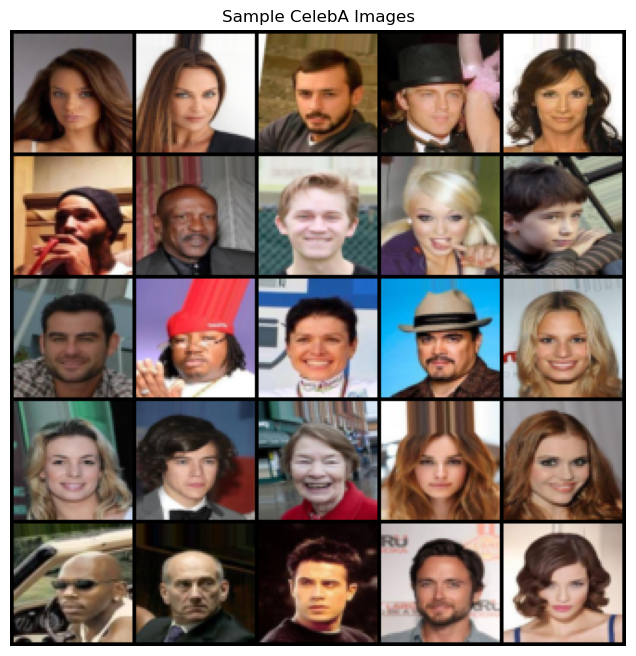

In [21]:
def show_images(dataloader, num_images=25):
    """Utility to display a grid of images from the dataloader."""
    sample_iter = iter(dataloader)
    images, _ = next(sample_iter)

    # Plot the first `num_images` images
    grid = make_grid(images[:num_images], nrow=5, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title("Sample CelebA Images")
    plt.show()

# Display a mini-batch of real images
show_images(dataloader)

## 3. Basic WGAN Implementation

As mentioned, WGAN tries to approximate the Wasserstein distance by learning a 1-Lipschitz critic. Below, we define:
- **Generator**: Based on DCGAN-like architecture for 64x64 images.
- **Critic/Discriminator**: Also DCGAN-like, but outputs a single scalar (no sigmoid).

We **do not** enforce the 1-Lipschitz constraint here via weight clipping or gradient penalty—this is the baseline "vanilla" WGAN code. In practice, weight clipping is often replaced by WGAN-GP or Spectral Norm.

In [22]:
class Reshape(nn.Module):
    """
    Utility layer to reshape incoming feature maps.

    Example usage:
        Reshape(-1, 128, 4, 4)  # -1 means "batch size remains the same"
    """
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(*self.shape)
    

class Generator(nn.Module):
    """
    Generator for WGAN, designed to create 64x64x3 images from a latent vector z.
    
    Args:
        z_dim (int): Dimension of the latent space.
        base_channels (int): Number of base feature maps. Adjust for model capacity.
    """
    def __init__(self, z_dim: int = 100, base_channels: int = 64):
        super().__init__()
        self.z_dim = z_dim

        # Sequential layers
        self.main = nn.Sequential(
            # Input: (N, z_dim) -> (N, base_channels*8, 4, 4)
            nn.Linear(z_dim, base_channels * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(base_channels * 8 * 4 * 4),
            nn.ReLU(inplace=True),

            # Reshape to (N, base_channels*8, 4, 4)
            Reshape(-1, base_channels * 8, 4, 4),

            # Upsample layers
            # (N, base_channels*8, 4, 4) -> (N, base_channels*4, 8, 8)
            nn.ConvTranspose2d(base_channels*8, base_channels*4, kernel_size=5, stride=2, 
                                padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(inplace=True),

            # (N, base_channels*4, 8, 8) -> (N, base_channels*2, 16, 16)
            nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=5, stride=2, 
                                padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(inplace=True),

            # (N, base_channels*2, 16, 16) -> (N, base_channels, 32, 32)
            nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=5, stride=2, 
                                padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),

            # (N, base_channels, 32, 32) -> (N, 3, 64, 64)
            nn.ConvTranspose2d(base_channels, 3, kernel_size=5, stride=2, 
                                padding=2, output_padding=1, bias=False),
            nn.Tanh()  # Force output to be in [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the generator.

        Args:
            z (torch.Tensor): Random noise tensor of shape (N, z_dim).

        Returns:
            torch.Tensor: Generated image of shape (N, 3, 64, 64).
        """
        return self.main(z)


class Discriminator(nn.Module):
    """
    Critic/Discriminator network for WGAN, outputs a single scalar score per image.
    
    Args:
        in_channels (int): Number of input channels, typically 3 for RGB images.
        base_channels (int): Number of base feature maps. Adjust for model capacity.
    """
    def __init__(self, in_channels: int = 3, base_channels: int = 64):
        super().__init__()

        self.main = nn.Sequential(
            # (N, 3, 64, 64) -> (N, base_channels, 32, 32)
            nn.Conv2d(in_channels, base_channels, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, base_channels, 32, 32) -> (N, base_channels*2, 16, 16)
            nn.Conv2d(base_channels, base_channels*2, kernel_size=5, stride=2, padding=2),
            nn.InstanceNorm2d(base_channels*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, base_channels*2, 16, 16) -> (N, base_channels*4, 8, 8)
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=5, stride=2, padding=2),
            nn.InstanceNorm2d(base_channels*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, base_channels*4, 8, 8) -> (N, base_channels*8, 4, 4)
            nn.Conv2d(base_channels*4, base_channels*8, kernel_size=5, stride=2, padding=2),
            nn.InstanceNorm2d(base_channels*8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # (N, base_channels*8, 4, 4) -> (N, 1, 1, 1)
            nn.Conv2d(base_channels*8, 1, kernel_size=4, stride=1),
            # Flatten for final scalar
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the critic/discriminator.

        Args:
            x (torch.Tensor): Image tensor of shape (N, in_channels, 64, 64).

        Returns:
            torch.Tensor: Critic score of shape (N, ) (a single scalar per image).
        """
        out = self.main(x)
        return out.view(-1)

### 3.1 Training Loop for WGAN

**Key points**:
- Train the **critic** more frequently than the generator (e.g., 5 critic steps per generator step).
- **Critic loss**: 
  $$
  L_D \;=\; -\mathbb{E}[\text{D(real)}] \;+\; \mathbb{E}[\text{D(fake)}].
  $$
- **Generator loss**: 
  $$
  L_G \;=\; -\mathbb{E}[\text{D(fake)}].
  $$

The code below implements these steps. **Weight clipping** (from the original WGAN paper) is not shown here—if you want to replicate that approach, you can clamp the critic weights after each update.  

Instead, we will see more sophisticated constraints (like Gradient Penalty or Spectral Normalization) in subsequent sections.

In [23]:
def train_wgan(
    generator: nn.Module,
    discriminator: nn.Module,
    dataloader: DataLoader,
    z_dim: int = 100,
    n_epochs: int = 5,
    lr: float = 2e-4,
    b1: float = 0.5,
    b2: float = 0.9,
    n_critic: int = 5
):
    """
    Train a WGAN model (no gradient penalty, no spectral norm).

    Args:
        generator (nn.Module): Generator model.
        discriminator (nn.Module): Discriminator (critic) model.
        dataloader (DataLoader): DataLoader for real images.
        z_dim (int): Dimensionality of the latent vector.
        n_epochs (int): Number of epochs.
        lr (float): Learning rate.
        b1 (float): Beta1 for Adam.
        b2 (float): Beta2 for Adam.
        n_critic (int): Number of critic iterations per generator iteration.
    """
    # Optimizers
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))
    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))

    # Create a fixed noise vector to visualize progress
    fixed_noise = torch.randn(16, z_dim, device=device)

    # Training
    step = 0
    generator.train()
    discriminator.train()

    for epoch in range(n_epochs):
        pbar = tqdm(dataloader, desc=f"Epoch [{epoch+1}/{n_epochs}]")
        for i, (real_imgs, _) in enumerate(pbar):
            real_imgs = real_imgs.to(device)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            for _ in range(n_critic):
                z = torch.randn(real_imgs.size(0), z_dim, device=device)
                fake_imgs = generator(z)

                d_optimizer.zero_grad()
                real_score = discriminator(real_imgs)
                fake_score = discriminator(fake_imgs.detach())

                d_loss = -torch.mean(real_score) + torch.mean(fake_score)
                d_loss.backward()
                d_optimizer.step()

            # -----------------
            #  Train Generator
            # -----------------
            z = torch.randn(real_imgs.size(0), z_dim, device=device)
            fake_imgs = generator(z)

            g_optimizer.zero_grad()
            fake_score = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_score)
            g_loss.backward()
            g_optimizer.step()

            pbar.set_postfix({
                "D_loss": d_loss.item(),
                "G_loss": g_loss.item(),
            })

            step += 1

        # -------------------------------------------------
        # After each epoch, generate sample images for validation
        # -------------------------------------------------
        generator.eval()
        with torch.no_grad():
            sample_imgs = generator(fixed_noise).cpu()

        grid = make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(6,6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.title(f"Epoch {epoch+1} - WGAN Generated Images")
        plt.axis("off")
        plt.show()

        generator.train()

    return generator, discriminator

Epoch [1/2]:   0%|          | 0/197 [00:00<?, ?it/s]

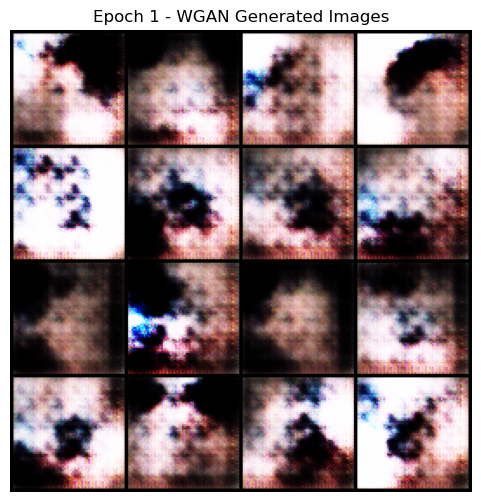

Epoch [2/2]:   0%|          | 0/197 [00:00<?, ?it/s]

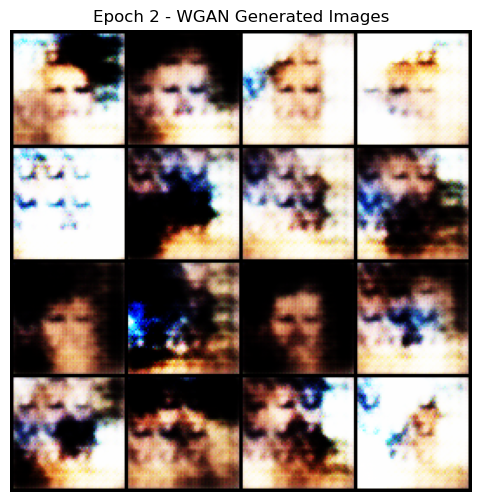

In [25]:
# Instantiate models
z_dim = 100
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

# Train
G, D = train_wgan(
    G, D, dataloader,
    z_dim=z_dim,
    n_epochs=2,
    lr=2e-4,
    b1=0.5,
    b2=0.9,
    n_critic=5
)

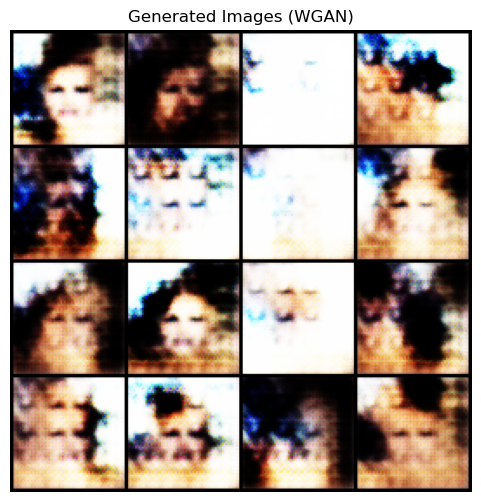

In [26]:
# Generate sample images
G.eval()
z_sample = torch.randn(16, z_dim, device=device)
with torch.no_grad():
    fake_imgs = G(z_sample).cpu()
grid = make_grid(fake_imgs, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Generated Images (WGAN)")
plt.axis("off")
plt.show()

## 4. WGAN-GP (Gradient Penalty)

The original WGAN paper used **weight clipping** to enforce that the critic function $D$ is 1-Lipschitz. However, weight clipping can be too crude and degrade performance.

**WGAN-GP** proposes a better approach: **Gradient Penalty**, where we explicitly penalize the critic if its gradient norm deviates from 1 on randomly-interpolated samples.

### 4.1 Gradient Penalty Formula

For real data samples $x$ and generated samples $\tilde{x} = G(z)$, we define an interpolation "interpolated samples":
$$
\hat{x} \;=\; \alpha\, x + (1 - \alpha)\,\tilde{x}, \quad \text{where} \; \alpha \sim U(0, 1).
$$

now we compute the critic output for the previous "interpolated" samples, then caluclate the gradients for this critic output, measure the norm for the gradients, and finally compute penality term 


Then the **gradient penalty** is:
$$
\mathcal{L}_{\mathrm{GP}} \;=\; \lambda \,\mathbb{E}_{\hat{x}} \Bigl[\bigl(\|\nabla_{\hat{x}}D(\hat{x})\|_2 - 1\bigr)^2\Bigr],
$$
where $\lambda$ is a hyperparameter. 

### 4.2 WGAN-GP Critic Loss

Putting this into the critic loss, we get:
$$
L_D^{(\mathrm{GP})} \;=\; \mathbb{E}\bigl[D(\tilde{x})\bigr] \;-\; \mathbb{E}\bigl[D(x)\bigr] \;+\; \lambda \, \mathbb{E}\bigl[(\|\nabla_{\hat{x}}D(\hat{x})\|_2 - 1)^2\bigr].
$$

$$
   
   L_D = -\mathbb{E}[D(x_{\text{real}})] + \mathbb{E}[D(x_{\text{fake}})] + \lambda \, \mathbb{E}\left[ \left( \|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1 \right)^2 \right]
   
   
$$

The gradient penalty enforces that $\nabla_{\hat{x}} D(\hat{x})$ has norm close to 1, pushing $D$ to be 1-Lipschitz in practice.

### 4.3. Intuition Behind the Penalty

- **If the gradient norm is exactly 1:**  
  $(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1 = 0)$, and there’s no penalty.
  
- **If the gradient norm is larger or smaller than 1:**  
  The penalty increases quadratically, forcing the critic to adjust so that its gradient stays close to 1.

This method allows the critic to learn more flexibly while still ensuring the Lipschitz constraint is respected, leading to more stable and effective training compared to weight clipping.



In [27]:
def gradient_penalty(discriminator, real_samples, fake_samples, device="cpu"):
    """
    Computes the gradient penalty for WGAN-GP.

    Args:
        discriminator (nn.Module): The critic.
        real_samples (torch.Tensor): A batch of real samples.
        fake_samples (torch.Tensor): A batch of generated (fake) samples.
        device (str): Device to run on.

    Returns:
        torch.Tensor: A scalar representing the gradient penalty.
    """
    # alpha ~ Uniform(0,1)
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)  # broadcast to match shape

    # \hat{x} = alpha * x_real + (1-alpha) * x_fake
    interpolates = alpha * real_samples + ((1 - alpha) * fake_samples)
    interpolates.requires_grad_(True)

    # Critic output on interpolated samples
    d_interpolates = discriminator(interpolates)
    grad_outputs = torch.ones_like(d_interpolates, device=device)

    # Get gradients w.r.t. the interpolated images
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    # Flatten the gradients to (batch_size, all_features)
    gradients = gradients.view(gradients.size(0), -1)
    grad_norm = gradients.norm(2, dim=1)  # L2 norm per sample
    penalty = ((grad_norm - 1) ** 2).mean()
    return penalty

In [28]:
def train_wgan_gp(
    generator: nn.Module,
    discriminator: nn.Module,
    dataloader: DataLoader,
    z_dim: int = 100,
    n_epochs: int = 5,
    lr: float = 2e-4,
    b1: float = 0.5,
    b2: float = 0.9,
    lambda_gp: float = 10.0,
    n_critic: int = 5
):
    """
    Train a WGAN-GP model (with gradient penalty).

    Args:
        generator (nn.Module): Generator model.
        discriminator (nn.Module): Discriminator (critic) model.
        dataloader (DataLoader): Dataloader for real images.
        z_dim (int): Dimensionality of the latent vector.
        n_epochs (int): Number of epochs.
        lr (float): Learning rate.
        b1 (float): Beta1 for Adam.
        b2 (float): Beta2 for Adam.
        lambda_gp (float): Gradient penalty coefficient.
        n_critic (int): Number of critic iterations per generator iteration.
    """
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))
    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))

    fixed_noise = torch.randn(16, z_dim, device=device)

    generator.train()
    discriminator.train()
    step = 0

    for epoch in range(n_epochs):
        pbar = tqdm(dataloader, desc=f"Epoch [{epoch+1}/{n_epochs}]")
        for i, (real_imgs, _) in enumerate(pbar):
            real_imgs = real_imgs.to(device)

            # Train the critic multiple times
            for _ in range(n_critic):
                z = torch.randn(real_imgs.size(0), z_dim, device=device)
                fake_imgs = generator(z)

                d_optimizer.zero_grad()
                real_score = discriminator(real_imgs)
                fake_score = discriminator(fake_imgs.detach())

                gp = gradient_penalty(discriminator, real_imgs, fake_imgs, device=device)
                d_loss = (
                    -torch.mean(real_score)
                    + torch.mean(fake_score)
                    + lambda_gp * gp
                )
                d_loss.backward()
                d_optimizer.step()

            # Train the generator
            z = torch.randn(real_imgs.size(0), z_dim, device=device)
            fake_imgs = generator(z)

            g_optimizer.zero_grad()
            fake_score = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_score)
            g_loss.backward()
            g_optimizer.step()

            pbar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}",
            })
            step += 1

        generator.eval()
        with torch.no_grad():
            sample_imgs = generator(fixed_noise).cpu()

        grid = make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(6,6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.title(f"Epoch {epoch+1} - WGAN-GP Generated Images")
        plt.axis("off")
        plt.show()

        generator.train()

    return generator, discriminator

In [ ]:
# Instantiate fresh models
z_dim = 100
G_gp = Generator(z_dim=z_dim).to(device)
D_gp = Discriminator().to(device)

# Train WGAN-GP
G_gp, D_gp = train_wgan_gp(
    G_gp, D_gp, dataloader,
    z_dim=z_dim,
    n_epochs=2,
    lr=2e-4,
    b1=0.5,
    b2=0.9,
    lambda_gp=10.0,
    n_critic=5
)

In [ ]:
# Generate some images
G_gp.eval()
z_sample = torch.randn(16, z_dim, device=device)
with torch.no_grad():
    fake_imgs_gp = G_gp(z_sample).cpu()
    
grid_gp = make_grid(fake_imgs_gp, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6,6))
plt.imshow(grid_gp.permute(1, 2, 0).numpy())
plt.title("Generated Images (WGAN-GP)")
plt.axis("off")
plt.show()

**WGAN-GP** is often more stable and effective in generating higher-quality outputs. It’s a more robust solution for training GANs at the **cost of higher computational complexity**.


**WGAN with Spectral Normalization** is a more lightweight approach that may be easier to implement and tune, and it’s more efficient in terms of memory and computation.



## 5. WGAN with Spectral Normalization

An alternative to gradient penalty is **Spectral Normalization**. The idea is:

$$
\hat{W} \;=\; \frac{W}{\sigma(W)},
$$

where $\sigma(W)$ is the largest singular value of the weight matrix $W$. By dividing the layer weights by $\sigma(W)$, we ensure the operator norm is $\le 1$. This effectively enforces a Lipschitz constraint on each layer.

In **PyTorch**, we can apply spectral normalization via:
```python
from torch.nn.utils import spectral_norm
layer = spectral_norm(nn.Conv2d(...))
```

**WGAN + Spectral Norm** can offer stable training without needing to tune $\lambda$ for the gradient penalty, though both methods aim for the same 1-Lipschitz requirement.

In [29]:
class DiscriminatorSN(nn.Module):
    """
    Discriminator/Critic with Spectral Normalization applied to convolutional layers.
    """
    def __init__(self, in_channels=3, base_channels=64):
        super().__init__()

        def block(in_ch, out_ch):
            # A small helper to create a spectral-normed conv block
            return nn.Sequential(
                spectral_norm(
                    nn.Conv2d(in_ch, out_ch, kernel_size=5, stride=2, padding=2)
                ),
                nn.InstanceNorm2d(out_ch, affine=True),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.main = nn.Sequential(
            spectral_norm(
                nn.Conv2d(in_channels, base_channels, kernel_size=5, stride=2, padding=2)
            ),
            nn.LeakyReLU(0.2, inplace=True),

            block(base_channels, base_channels*2),
            block(base_channels*2, base_channels*4),
            block(base_channels*4, base_channels*8),

            spectral_norm(
                nn.Conv2d(base_channels*8, 1, kernel_size=4, stride=1)
            ),
        )

    def forward(self, x):
        out = self.main(x)
        return out.view(-1)

In [30]:
def train_wgan_sn(
    generator: nn.Module,
    discriminator: nn.Module,
    dataloader: DataLoader,
    z_dim: int = 100,
    n_epochs: int = 5,
    lr: float = 2e-4,
    b1: float = 0.5,
    b2: float = 0.9,
    n_critic: int = 5
):
    """
    Train a WGAN model with Spectral Normalization on the critic.

    Args:
        generator (nn.Module): Generator model.
        discriminator (nn.Module): Discriminator (critic) model.
        dataloader (DataLoader): Dataloader for real images.
        z_dim (int): Dimensionality of the latent vector.
        n_epochs (int): Number of epochs.
        lr (float): Learning rate.
        b1 (float): Beta1 for Adam.
        b2 (float): Beta2 for Adam.
        n_critic (int): Number of critic iterations per generator iteration.
    """
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))
    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))

    fixed_noise = torch.randn(16, z_dim, device=device)

    generator.train()
    discriminator.train()
    step = 0

    for epoch in range(n_epochs):
        pbar = tqdm(dataloader, desc=f"Epoch [{epoch+1}/{n_epochs}]")
        for i, (real_imgs, _) in enumerate(pbar):
            real_imgs = real_imgs.to(device)

            # Train the critic multiple times
            for _ in range(n_critic):
                z = torch.randn(real_imgs.size(0), z_dim, device=device)
                fake_imgs = generator(z)

                d_optimizer.zero_grad()
                real_score = discriminator(real_imgs)
                fake_score = discriminator(fake_imgs.detach())

                # WGAN loss for the critic
                d_loss = -torch.mean(real_score) + torch.mean(fake_score)
                d_loss.backward()
                d_optimizer.step()

            # Train the generator
            z = torch.randn(real_imgs.size(0), z_dim, device=device)
            fake_imgs = generator(z)

            g_optimizer.zero_grad()
            fake_score = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_score)
            g_loss.backward()
            g_optimizer.step()

            pbar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })
            step += 1

        generator.eval()
        with torch.no_grad():
            sample_imgs = generator(fixed_noise).cpu()

        grid = make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(6,6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.title(f"Epoch {epoch+1} - WGAN-SN Generated Images")
        plt.axis("off")
        plt.show()

        generator.train()

    return generator, discriminator

In [31]:
# Instantiate fresh models for WGAN-SN
z_dim = 100
G_sn = Generator(z_dim=z_dim).to(device)
D_sn = DiscriminatorSN().to(device)

In [33]:
# Train
G_sn, D_sn = train_wgan_sn(
    G_sn, D_sn, dataloader,
    z_dim=z_dim,
    n_epochs=20,
    lr=2e-4,
    b1=0.5,
    b2=0.9,
    n_critic=5
)

'# Train\nG_sn, D_sn = train_wgan_sn(\n    G_sn, D_sn, dataloader,\n    z_dim=z_dim,\n    n_epochs=20,\n    lr=2e-4,\n    b1=0.5,\n    b2=0.9,\n    n_critic=5\n)'

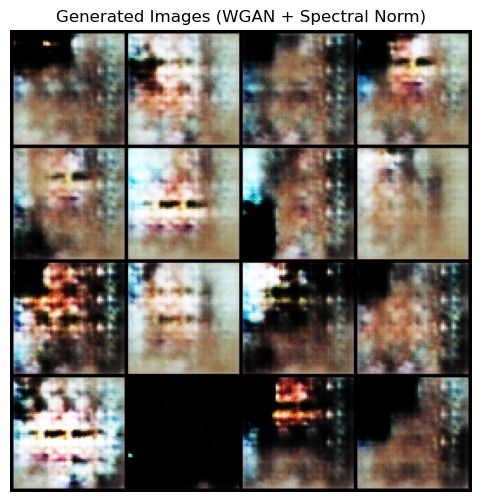

In [10]:
# Generate images
G_sn.eval()
z_sample = torch.randn(16, z_dim, device=device)
with torch.no_grad():
    fake_imgs_sn = G_sn(z_sample).cpu()
    
grid_sn = make_grid(fake_imgs_sn, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6,6))
plt.imshow(grid_sn.permute(1, 2, 0).numpy())
plt.title("Generated Images (WGAN + Spectral Norm)")
plt.axis("off")
plt.show()

# 6. Conclusion

We have walked through three popular approaches to Wasserstein GANs:

1. **WGAN** (basic)  
2. **WGAN-GP** (with gradient penalty)  
3. **WGAN + Spectral Normalization**  

**Key Takeaways**:
1. WGANs often converge more stably than classical GANs using JS-divergence or KL-divergence.  
2. The **1-Lipschitz constraint** is crucial for a correct estimation of the Wasserstein distance.  
   - Weight clipping (original WGAN) can be too simplistic.  
   - Gradient Penalty (WGAN-GP) or Spectral Normalization often yields better, more stable results.  
   - (WGAN-GP) is more computationally expensive and it depends on the hyperparameters compared to WGAN-SP but also it can be more stable and effective.

Here’s a table comparing **GAN, f-GAN, and WGAN** based on key characteristics:  

| Feature          | **GAN** (Goodfellow et al.) | **f-GAN** (Nowozin et al.) | **WGAN** (Arjovsky et al.) |
|-----------------|---------------------------|---------------------------|---------------------------|
| **Objective**   | Minimize **Jensen-Shannon (JS) divergence** between real and generated distributions. | Minimize a **general f-divergence** (e.g., KL, reverse KL, JSD, etc.). | Minimize **Wasserstein (Earth-Mover) distance** between distributions. |
| **Discriminator / Critic** | **Classifier** (outputs probability that a sample is real). | **f-Divergence estimator** (learns an activation-based function for divergence). | **Critic** (outputs a real-valued score instead of a probability). |
| **Loss Function** | Binary cross-entropy (log loss). | Custom f-divergence-based loss (depends on the chosen divergence). | Wasserstein loss: \( E[D(fake)] - E[D(real)] \). |
| **Mode Collapse Handling** | Prone to mode collapse due to JS divergence. | Depends on the chosen divergence; some choices handle mode collapse better than JS. | **Better** because Wasserstein distance provides meaningful gradients even when distributions don’t overlap. |
| **Training Stability** | **Unstable** due to vanishing gradients and mode collapse. | More flexible but still suffers from adversarial training difficulties. | **More stable** due to smoother loss function. |
| **Lipschitz Constraint** | ❌ **No explicit constraint.** | ❌ **No explicit constraint.** | ✅ **Requires a 1-Lipschitz constraint on the critic.** |
| **Constraint Enforcement** | Implicitly via sigmoid in discriminator. | Implicitly through the choice of f-divergence. | ✅ **WGAN:** Uses **weight clipping**. <br> ✅ **WGAN-GP:** Uses **gradient penalty**. <br> ✅ **WGAN-SN:** Uses **spectral normalization**. |
| **Gradient Quality** | Poor gradients when real and fake distributions don’t overlap. | Can be better if the right f-divergence is chosen. | **Good** gradients almost always (thanks to Wasserstein loss). |
| **Practical Use Cases** | Image synthesis (e.g., DCGAN, StyleGAN). | Theoretical framework to unify different divergences. | **More stable GAN training** → Used in many real-world applications. |

### **Key Takeaways:**
- **GAN**: The most common but has stability issues and mode collapse.  
- **f-GAN**: Generalized framework using different divergence measures instead of JS divergence.  
- **WGAN**: More stable training using Wasserstein distance and Lipschitz constraints.  

